# Authorship Verification of the Disputed Pauline Letters through Deep Learning – Jupyter Notebook

This Jupyter Notebook contains code for the project "Authorship Verification of the Disputed Pauline Letters through Deep Learning" by Evy Beijen and Rianne de Heide, published in *HIPHIL Novum*. The study presents a deep learning approach to the authorship verification of the disputed Pauline letters. Specifically, we developed two variants of a bidirectional LSTM network—one trained on plaintext data and one on lemmatized text data—to classify segments of the disputed Pauline letters, each approximately 100 words long, as either authored by Paul or not. This notebook represents a cleaned and reorganized version of the original notebook created in the first half of 2024, which generated the results reported in the article. These revisions, made in March-April 2026, were undertaken to improve readability; no modifications were made that affected the results generated by this code.

**Citation for the article**: Beijen, Evy, and Rianne de Heide. 2025. "Authorship Verification of the Disputed Pauline Letters through Deep Learning." *HIPHIL Novum* 10 (1): 22–39. https://doi.org/10.7146/hn.v10i1.147482. 


To run this notebook, a Python environment can be set up using the specifications in `environment.yml`, included in this GitHub repository. Furthermore, the notebook relies on functions from two Python files, also included in this repository:

- `preprocessing.py`
- `model_creation_and_hyperparameter_tuning.py`


As noted in the article, the Greek text data used for the project were retrieved from the websites of the *Society of Biblical Literature* (SBL) and the *Christian Classics Ethereal Library* (CCEL): 

- Society of Biblical Literature (SBL). 2023. *SBL Greek New Testament*. GitHub. Version 1.2. Accessed February 24, 2024. https://github.com/LogosBible/SBLGNT.
- Lake, Kirsopp, ed. 1913. *The Apostolic Fathers*. Christian Classics Ethereal Library (CCEL). Accessed March 2, 2024. https://www.ccel.org/l/lake/fathers/toc.htm.   

They were saved as `.txt` files in structured folders:

- Undisputed Pauline letters: `Data/Paul/*.txt`  
- Disputed Pauline letters: `Data/Disputed/*.txt`  
- Imposter letters: `Data/John/*.txt`, `Data/Jude/*.txt`, `Data/James/*.txt`, `Data/Peter1/*.txt`, `Data/Peter2/*.txt`, `Data/Ignatius/*.txt`, `Data/Barnabas/*.txt`, `Data/Clement/*.txt`

To run the notebook, the text data needs to be retrieved from the mentioned sources and saved according to the structure indicated above. Users are responsible for reviewing and complying with the copyright and licensing terms of these sources before downloading, using or redistributing the text data.

**Article-reproduction note:** The `.txt` file for 1 Clement originally used in this project is missing the last part of the letter (sections XLVII-LXV) due to a copy-pasting error. To replicate the article pipeline, exclude these sections. If including the full text, note that this will increase class imbalance (i.e., more imposter text chunks).

The order of steps in this notebook differs slightly from the sequence in which the methodology is presented in the article, but the underlying methodological procedure is equivalent.

## Importing packages and data

In [2]:
import os
import re
import random
import numpy as np

from cltk import NLP

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from bayes_opt import BayesianOptimization, UtilityFunction
import time
import warnings

import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
data_dir = os.path.join("..", "Data")

# (Un)disputed Pauline letters to be stored in dictionaries
paul_texts = {}
disputed_texts = {}

# Imposter letters to be stored in separate lists
john_texts = []
james_texts = []
jude_texts = []
peter1_texts = []
peter2_texts = []
ign_texts = []
barn_texts = []
clem_texts = []

folder_names = ["Paul", "Disputed", "John", "Jude", "James", "Peter1", "Peter2", "Ignatius", "Barnabas", "Clement"]

for folder in os.listdir(data_dir):
    folder_path = os.path.join(data_dir, folder)
    if os.path.isdir(folder_path) and folder in folder_names:
        # Iterate over the .txt files in the current folder
        for filename in os.listdir(folder_path):
            file_path = os.path.join(folder_path, filename)
            if os.path.isfile(file_path) and filename.endswith('.txt'):
                # Read the contents of the .txt file and add to corresponding dictionaries/lists
                with open(file_path, 'r') as file:
                    text = file.read()
                    if folder == "Paul":
                        paul_texts[filename]=text
                    elif folder == "Disputed":
                        disputed_texts[filename] = text
                    elif folder == "John":
                        john_texts.append(text)
                    elif folder == "Jude":
                        jude_texts.append(text)
                    elif folder == "James":
                        james_texts.append(text)
                    elif folder == "Peter1":
                        peter1_texts.append(text)
                    elif folder == "Peter2":
                        peter2_texts.append(text)
                    elif folder == "Ignatius":
                        ign_texts.append(text)
                    elif folder == "Barnabas":
                        barn_texts.append(text)
                    elif folder == "Clement":
                        clem_texts.append(text)


## Initial preprocessing

In [6]:
# Importing preprocessing functions from .py file
from preprocessing import remove_accentuation, remove_punctuation, remove_specific_names, clean_text, split_text_into_chunks

# Additional cleaning needed for non-canonical letters due to differences in file formatting
def extra_cleaning_noncanonical_letters(text):
    
    # Remove Roman numerals (section markers)
    cleaned_text = re.sub(r'\b[IVXLCDM]+\b', '', text)

    # Remove numbers followed by a period and space (verse numbers)
    cleaned_text = re.sub(r'\b\d+\.\s', '', cleaned_text)

    return cleaned_text

In [7]:
# (Un)disputed Pauline letter chunks to be stored in dictionaries
paul_chunks = {}
disputed_chunks = {}

# Imposter letter chunks to be stored in separate lists
john_chunks = []
james_chunks = []
jude_chunks = []
peter1_chunks = []
peter2_chunks = []
ign_chunks = []
barn_chunks = []
clem_chunks = []


names_to_remove = ['παυλος', 'παυλου', 'ιακωβος', 'ιουδας', 'πετρος', 'ιγνατιος']


for file_name, text in paul_texts.items():
    cleaned_text = clean_text(text, names_to_remove, exceptions={".", "·"})
    paul_chunks[file_name] = split_text_into_chunks(cleaned_text, delimiters={".", "·"})

for file_name, text in disputed_texts.items():
    cleaned_text = clean_text(text, names_to_remove, exceptions={".", "·"})
    disputed_chunks[file_name] = split_text_into_chunks(cleaned_text, delimiters={".", "·"})

# Iterate through the canonical imposter letters
for texts, cleaned_chunks in zip([john_texts, james_texts, jude_texts, peter1_texts, peter2_texts], 
                               [john_chunks, james_chunks, jude_chunks, peter1_chunks, peter2_chunks]):
    for text in texts:
        cleaned_text = clean_text(text, names_to_remove, exceptions={".", "·"})
        cleaned_chunks.extend(split_text_into_chunks(cleaned_text, delimiters={".", "·"}))

# Iterate through the non-canonical imposter letters
for texts, cleaned_chunks in zip([ign_texts, barn_texts, clem_texts], 
                               [ign_chunks, barn_chunks, clem_chunks]):
    for text in texts:
        cleaned_text = clean_text(extra_cleaning_noncanonical_letters(text), names_to_remove, exceptions={".", "·"})
        cleaned_chunks.extend(split_text_into_chunks(cleaned_text, delimiters={".", "·"}))

# Optional checks
#print(paul_chunks["Phlm.txt"])
#print(jude_chunks)

**Note**: In segmenting the texts into chunks of approximately 100 words, "." and "·" were used as delimiters (see `preprocessing.py` for the exact approach). If the study were repeated, we would consider other chunking strategies, such as including ";" as a delimiter; however, the code preserves our initial approach for reproducibility. The effects of alternative chunking strategies could be explored in future work.

In [8]:
# Creating subsets A, B and C (see article for more explanation)

# Subset A: training and testing
paul_chunks_A = []
for filename in paul_chunks.keys():
    if filename != "Phlm.txt" and filename != "Gal.txt":
        paul_chunks_A.extend(paul_chunks[filename])

imposter_chunks_A = john_chunks + james_chunks  + peter2_chunks + ign_chunks + barn_chunks + clem_chunks

subset_A = paul_chunks_A + imposter_chunks_A
labels_A = ['Paul'] * len(paul_chunks_A) + ['Other'] * len(imposter_chunks_A)


# Subset B: letters (with known authorship) left out of subset A
subset_B = {
    "1 Peter": peter1_chunks,
    "Jude": jude_chunks,
    "Philemon": paul_chunks["Phlm.txt"],
    "Galatians": paul_chunks["Gal.txt"]
}


# Subset C: disputed Pauline letters
# Renaming dictionary keys to full letter titles
title_map = {
    "1Tim.txt": "1 Timothy",
    "2Tim.txt": "2 Timothy",
    "Titus.txt": "Titus",
    "Eph.txt": "Ephesians",
    "Col.txt": "Colossians",
    "Heb.txt": "Hebrews",
    "2Thess.txt": "2 Thessalonians"
}

subset_C = {}
for letter, chunks in disputed_chunks.items():
    letter_title = title_map.get(letter, letter)
    subset_C[letter_title] = chunks

## Plaintext model

In [9]:
# Further preprocessing subset A

label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(labels_A)

tokenizer = Tokenizer()
tokenizer.fit_on_texts(subset_A)
vocab_size=len(tokenizer.word_index)+1

sequences = tokenizer.texts_to_sequences(subset_A)
max_sequence_length = max(len(seq) for seq in sequences)
sequences_padded = pad_sequences(sequences, maxlen=max_sequence_length, padding='post')

X_train, X_test, y_train, y_test = train_test_split(sequences_padded, labels_encoded, test_size=0.2, random_state=42)


**Article-reproduction note:** In the article pipeline, the tokenizer was fit on the full subset A before the train-test split. This means that words appearing only in the test portion of subset A are included in the vocabulary, although their embeddings are not updated during training. We retain this implementation here because the purpose of this notebook is to reproduce the article pipeline. For new research, we recommend fitting the tokenizer only on the training data to treat words outside the training vocabulary consistently as unknown tokens.

### Hyperparameter tuning, training and testing

In [10]:
# Importing required functions from .py file
from model_creation_and_hyperparameter_tuning import create_model, evaluate_model


**Note:** The hyperparameter tuning process below is computationally intensive. In our tests, it took about one hour to complete. 

In [ ]:
# Hyperparameter tuning through Bayesian optimization

# Ensuring deterministic execution
os.environ['TF_DETERMINISTIC_OPS'] = '1'
tf.keras.utils.set_random_seed(42)
session_conf = tf.compat.v1.ConfigProto(intra_op_parallelism_threads=1, inter_op_parallelism_threads=1)
sess = tf.compat.v1.Session(graph=tf.compat.v1.get_default_graph(), config=session_conf)
tf.compat.v1.keras.backend.set_session(sess)


def objective_function_tuning(embed_dim, lstm_units, dropout, learning_rate, epochs, batch_size):
    # Cast the parameters that should be integers
    embed_dim = int(embed_dim)
    lstm_units = int(lstm_units)
    epochs = int(epochs)
    batch_size = int(batch_size)
    
    return evaluate_model(embed_dim, lstm_units, dropout, learning_rate, epochs, batch_size, vocab_size, X_train, y_train)


pbounds = {'embed_dim': (50, 200), 'lstm_units': (50, 200), 'dropout': (0.1, 0.5), 
           'learning_rate': (0.001, 0.01),'epochs': (10, 20), 'batch_size': (32, 128)}

start = time.time()
warnings.filterwarnings("ignore")
optimizer = BayesianOptimization(f = objective_function_tuning, pbounds = pbounds, random_state = 43)
optimizer.maximize(init_points = 10, n_iter = 30)

print("Best result: {}; f(x) = {}.".format(optimizer.max["params"], optimizer.max["target"]))
print('It takes %s minutes' % ((time.time() - start)/60))

In [11]:
# Training and testing the model

# Ensuring deterministic execution
os.environ['TF_DETERMINISTIC_OPS'] = '1'
tf.keras.utils.set_random_seed(42)
session_conf = tf.compat.v1.ConfigProto(intra_op_parallelism_threads=1, inter_op_parallelism_threads=1)
sess = tf.compat.v1.Session(graph=tf.compat.v1.get_default_graph(), config=session_conf)
tf.compat.v1.keras.backend.set_session(sess)

# Tuned hyperparameter values (see article) filled in manually 
model = create_model(embed_dim=70, lstm_units=115, vocab_size=vocab_size, dropout=0.10339881584988651, learning_rate=0.001070605093208486)
model.fit(X_train, y_train, epochs=18, batch_size=73)

y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_test_decoded = label_encoder.inverse_transform(y_test)
y_pred_decoded = label_encoder.inverse_transform(y_pred)

print(classification_report(y_test_decoded, y_pred_decoded))

Epoch 1/18
7/7 [==============================] - 4s 110ms/step - loss: 0.6847 - accuracy: 0.5376
Epoch 2/18
7/7 [==============================] - 1s 106ms/step - loss: 0.6702 - accuracy: 0.5718
Epoch 3/18
7/7 [==============================] - 1s 106ms/step - loss: 0.6407 - accuracy: 0.7654
Epoch 4/18
7/7 [==============================] - 1s 106ms/step - loss: 0.4342 - accuracy: 0.8815
Epoch 5/18
7/7 [==============================] - 1s 106ms/step - loss: 0.2027 - accuracy: 0.9636
Epoch 6/18
7/7 [==============================] - 1s 105ms/step - loss: 0.1158 - accuracy: 0.9727
Epoch 7/18
7/7 [==============================] - 1s 139ms/step - loss: 0.0611 - accuracy: 0.9886
Epoch 8/18
7/7 [==============================] - 1s 139ms/step - loss: 0.0101 - accuracy: 0.9977
Epoch 9/18
7/7 [==============================] - 1s 124ms/step - loss: 0.1264 - accuracy: 0.9681
Epoch 10/18
7/7 [==============================] - 1s 107ms/step - loss: 0.0554 - accuracy: 0.9977
Epoch 11/18
7/7 [==

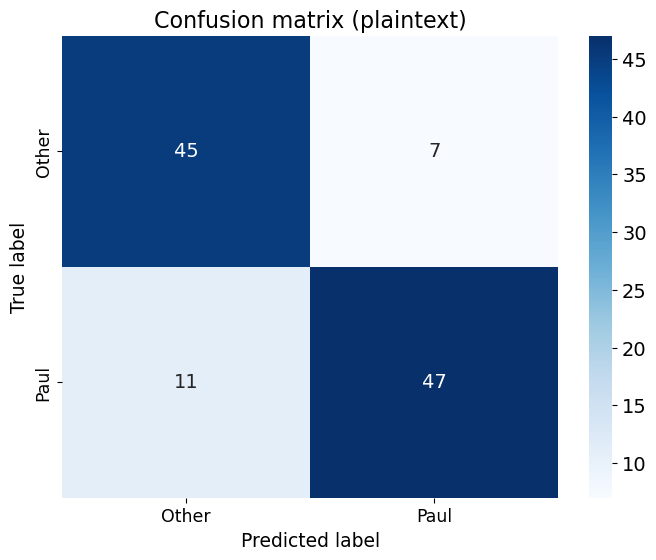

In [12]:
# Plot confusion matrix
conf_matrix = confusion_matrix(y_test_decoded, y_pred_decoded)

plt.figure(figsize=(8, 6))
heatmap = sns.heatmap(conf_matrix, annot=True, fmt=".0f", cmap='Blues', annot_kws={"fontsize": 14},
                     xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted label', fontsize=13.5)
plt.ylabel('True label', fontsize=13.5)
plt.title('Confusion matrix (plaintext)', fontsize=16)
plt.xticks(fontsize=12.5)
plt.yticks(fontsize=12.5)
cbar = heatmap.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)  

plt.show()

### Predictions

In [13]:
# Functions for predicting authorship for subsets B and C

def preprocess_chunks(chunks):
    sequences = tokenizer.texts_to_sequences(chunks)
    sequences_padded = pad_sequences(sequences, maxlen=max_sequence_length, padding='post')
    
    return sequences_padded


def get_predictions(chunks):
    preprocessed_chunks = preprocess_chunks(chunks)
    
    predictions_prob = model.predict(preprocessed_chunks)
    predicted_labels = label_encoder.inverse_transform(np.argmax(predictions_prob, axis=1))
    
    return predicted_labels, predictions_prob


def plot_probabilities(letter_title, subset, predictions_prob):
    color = "#006400" if subset == "B" else "#380282"
    
    probabilities_paul = predictions_prob[:, label_encoder.transform(['Paul'])[0]]
    chunk_numbers = range(1, len(probabilities_paul) + 1)

    plt.figure(figsize=(8, 6))
    plt.plot(chunk_numbers, probabilities_paul, marker='o', linestyle='-', color=color)
    plt.xlabel('Chunk number', fontsize=14)
    plt.ylabel('Probability of Paul', fontsize=14)
    plt.title(f'Predicted probabilities of Paul for {letter_title} (plaintext)', fontsize=16)

    num_ticks = min(10, len(probabilities_paul))
    step = max(1, len(probabilities_paul) // num_ticks)
    xticks_values = range(1, len(probabilities_paul) + 1, step)
    plt.xticks(xticks_values, fontsize=12)
    plt.yticks(fontsize=12)
    plt.ylim(-0.001, 1.03)
    
    plt.show()


def print_and_plot_predictions(letter_title, subset, chunks):
    predicted_labels, predictions_prob = get_predictions(chunks)
    
    print(f"Predicted author for chunks of {letter_title}:", predicted_labels)
    plot_probabilities(letter_title, subset, predictions_prob)
    
    return predicted_labels


1/1 [==============================] - 0s 50ms/step
Predicted author for chunks of 1 Peter: ['Paul' 'Other' 'Paul' 'Other' 'Other' 'Other' 'Other' 'Other' 'Other'
 'Other' 'Paul' 'Paul' 'Other' 'Other' 'Paul' 'Paul' 'Paul' 'Other' 'Paul']


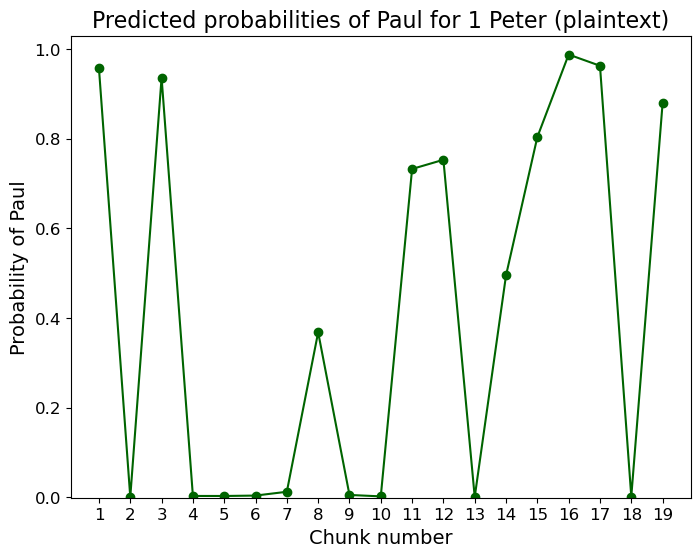

1/1 [==============================] - 0s 29ms/step
Predicted author for chunks of Jude: ['Other' 'Other' 'Paul' 'Other' 'Other' 'Paul']


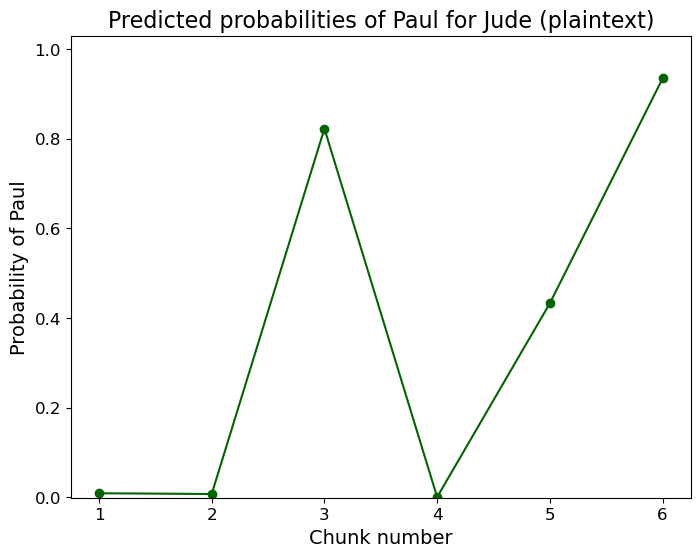

1/1 [==============================] - 0s 28ms/step
Predicted author for chunks of Philemon: ['Other' 'Paul' 'Paul' 'Paul']


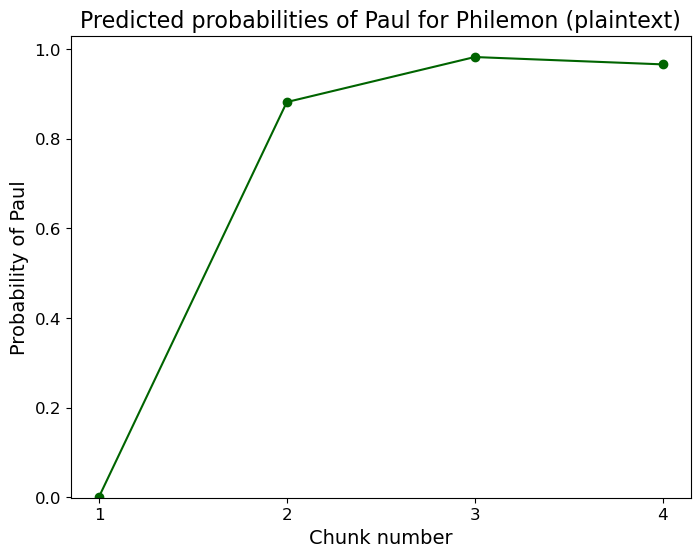

1/1 [==============================] - 0s 36ms/step
Predicted author for chunks of Galatians: ['Paul' 'Paul' 'Other' 'Other' 'Paul' 'Paul' 'Paul' 'Paul' 'Paul' 'Paul'
 'Paul' 'Paul' 'Paul' 'Paul' 'Other' 'Paul' 'Other' 'Other' 'Paul' 'Paul'
 'Paul' 'Paul' 'Paul' 'Paul' 'Paul']


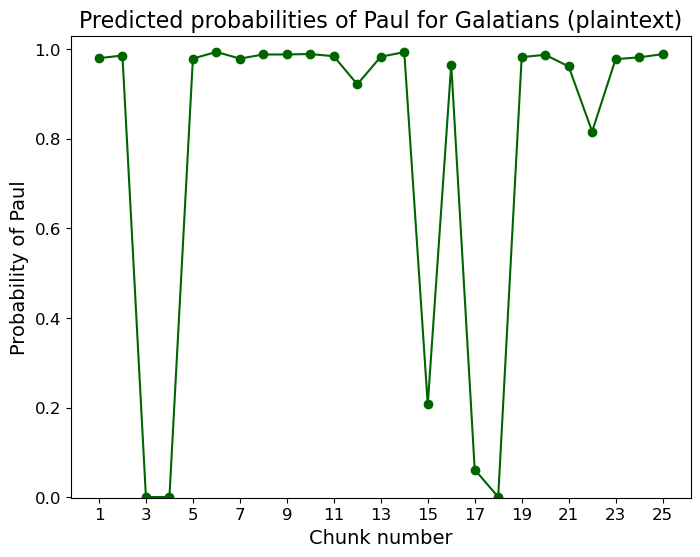

1/1 [==============================] - 0s 30ms/step
Predicted author for chunks of 2 Timothy: ['Paul' 'Paul' 'Paul' 'Other' 'Paul' 'Paul' 'Other' 'Other' 'Other'
 'Other' 'Other' 'Other' 'Other' 'Other' 'Paul']


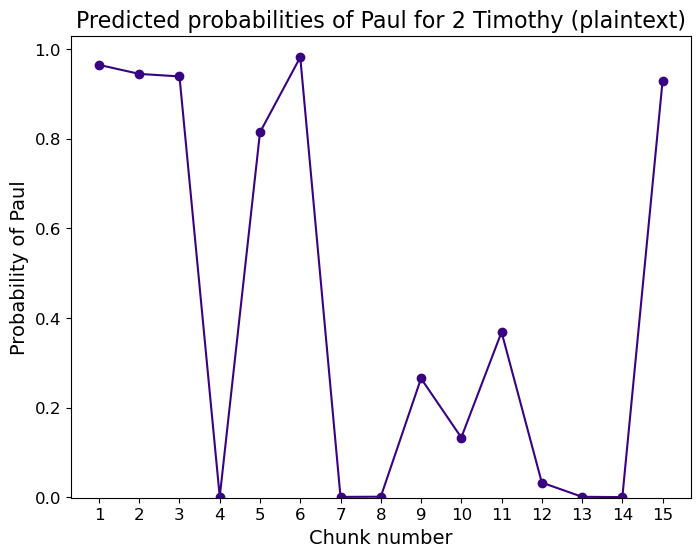

1/1 [==============================] - 0s 32ms/step
Predicted author for chunks of Titus: ['Other' 'Other' 'Other' 'Paul' 'Other' 'Paul' 'Other' 'Paul']


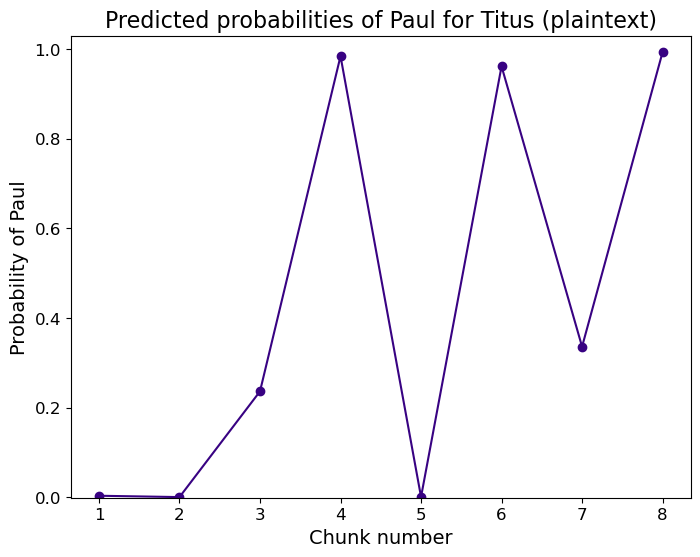

1/1 [==============================] - 0s 34ms/step
Predicted author for chunks of 2 Thessalonians: ['Paul' 'Other' 'Paul' 'Other' 'Other' 'Paul' 'Paul' 'Paul' 'Paul' 'Paul']


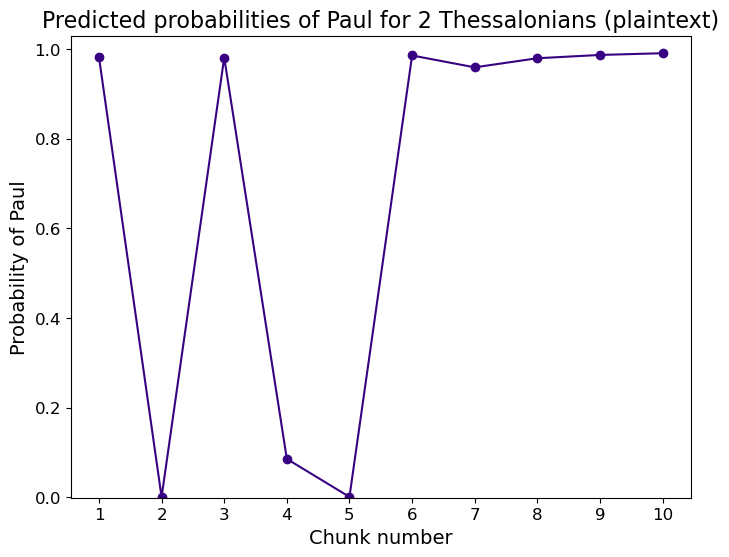

1/1 [==============================] - 0s 36ms/step
Predicted author for chunks of 1 Timothy: ['Other' 'Paul' 'Other' 'Other' 'Paul' 'Paul' 'Paul' 'Other' 'Other'
 'Other' 'Other' 'Paul' 'Paul' 'Other' 'Other' 'Other' 'Other' 'Other']


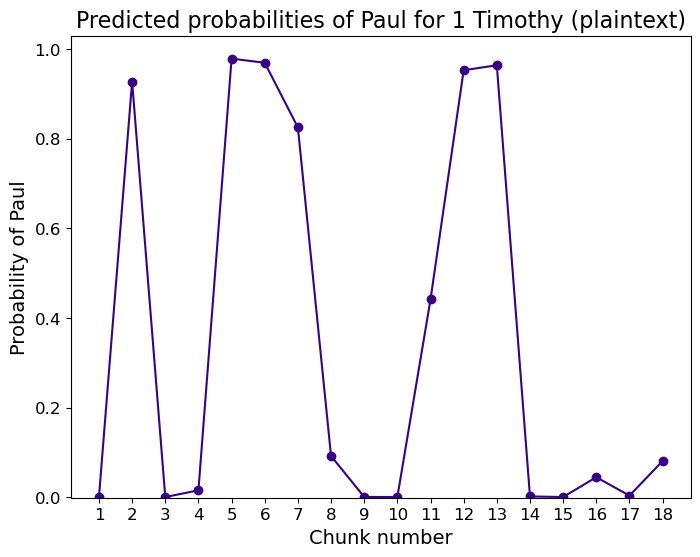

1/1 [==============================] - 0s 41ms/step
Predicted author for chunks of Ephesians: ['Paul' 'Other' 'Paul' 'Other' 'Other' 'Other' 'Paul' 'Other' 'Paul'
 'Other' 'Paul' 'Other' 'Paul' 'Paul' 'Paul' 'Other' 'Paul' 'Other'
 'Other' 'Paul' 'Other' 'Paul' 'Other' 'Other' 'Other' 'Paul' 'Paul'
 'Paul']


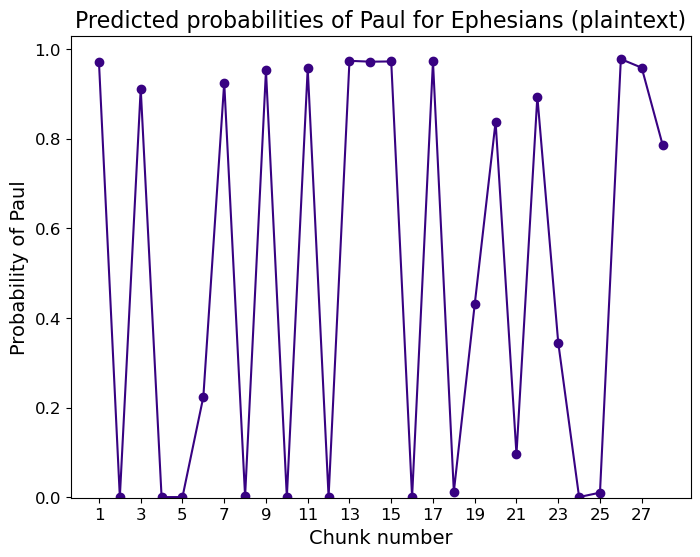

2/2 [==============================] - 0s 20ms/step
Predicted author for chunks of Hebrews: ['Other' 'Other' 'Other' 'Other' 'Paul' 'Other' 'Other' 'Other' 'Paul'
 'Other' 'Other' 'Other' 'Other' 'Other' 'Other' 'Paul' 'Other' 'Other'
 'Other' 'Other' 'Other' 'Paul' 'Paul' 'Other' 'Other' 'Other' 'Other'
 'Other' 'Paul' 'Other' 'Other' 'Other' 'Paul' 'Paul' 'Other' 'Paul'
 'Other' 'Other' 'Other' 'Paul' 'Other' 'Other' 'Other' 'Other' 'Other'
 'Other' 'Paul' 'Other' 'Paul' 'Paul' 'Paul' 'Other' 'Other' 'Other'
 'Other' 'Other' 'Paul' 'Paul']


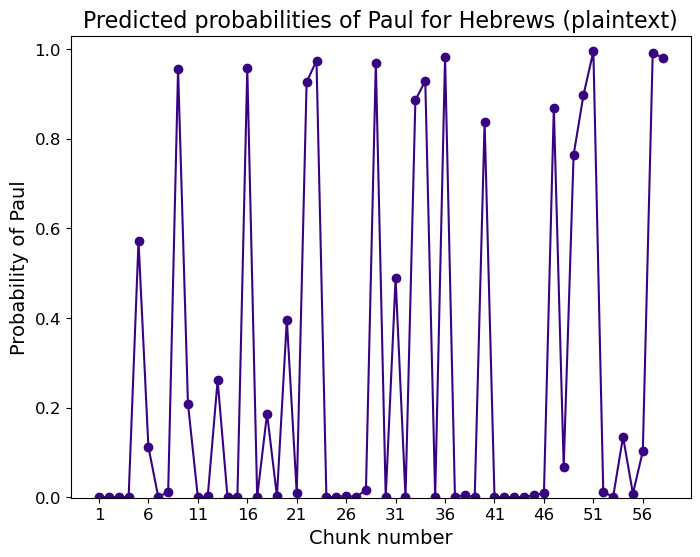

1/1 [==============================] - 0s 38ms/step
Predicted author for chunks of Colossians: ['Paul' 'Paul' 'Paul' 'Paul' 'Paul' 'Paul' 'Paul' 'Other' 'Paul' 'Other'
 'Paul' 'Other' 'Paul' 'Other' 'Other' 'Other' 'Other' 'Paul' 'Other'
 'Paul' 'Paul']


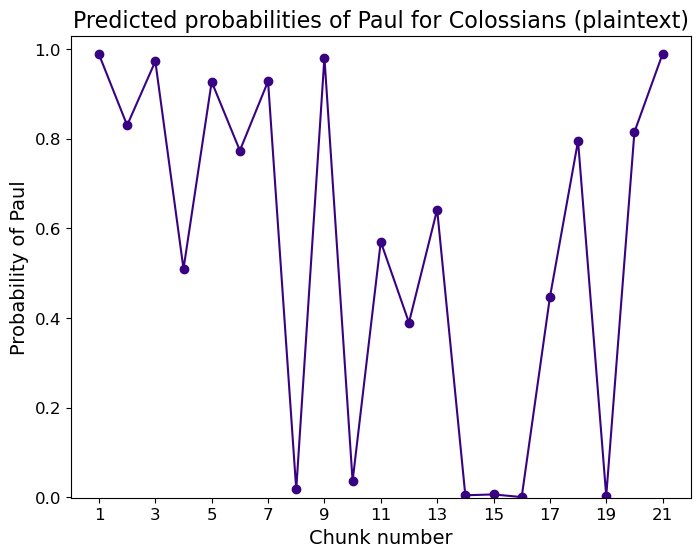

In [14]:
# Printing and plotting predictions for subsets B and C

# Subset B: letters (with known authorship) left out of subset A
for letter_title, chunks in subset_B.items():
    print_and_plot_predictions(letter_title, "B", chunks)

# Subset C: disputed Pauline letters
for letter_title, chunks in subset_C.items():
    print_and_plot_predictions(letter_title, "C", chunks)

## Lemmatized model

This section can be run separately from the plaintext section, but the initial preprocessing steps are assumed. Some code from the plaintext section is repeated here to ensure this section can indeed run independently.  

**Important reproducibility note:** In contrast to the plaintext model, exact replication of the results reported in the article was not achieved for the lemmatized model in 2026, even when using the exact same code. As the Python environment in which the code was run in 2026 (see `environment.yml`) does specify the same version (1.2.2) of the Classical Language Toolkit (CLTK) as initially used in 2024, we suspect the differences arise from updates in the dependencies used by CLTK, which can affect the lemmatization of the text chunks. Despite testing different versions of underlying packages, we have not found a combination that reproduces the article's results, with results varying across tested setups. This highlights the model's sensitivity to variations in preprocessing and we encourage further research in this area.


### Lemmatization and further preprocessing

In [15]:
# Lemmatizing subsets A, B and C
from preprocessing import lemmatize_text

subset_A_lem = [lemmatize_text(chunk) for chunk in subset_A]
labels_A_lem = labels_A

subset_B_lem = {}
for letter_title, chunks in subset_B.items():
    subset_B_lem[letter_title] = [lemmatize_text(chunk) for chunk in chunks]

subset_C_lem = {}
for letter_title, chunks in subset_C.items():
    subset_C_lem[letter_title] = [lemmatize_text(chunk) for chunk in chunks]

**Note:** The lemmatization of the text chunks was automated using CLTK, which introduced errors and left certain words unlemmatized. In hindsight, we realize that prior preprocessing steps, particularly the removal of accents, likely reduced lemmatization accuracy. We acknowledge this limitation and encourage future work to test the effects of different preprocessing strategies, including retaining accents before lemmatization.

In [16]:
# Further preprocessing subset A

label_encoder_lem = LabelEncoder()
labels_encoded_lem = label_encoder_lem.fit_transform(labels_A_lem)

tokenizer_lem = Tokenizer()
tokenizer_lem.fit_on_texts(subset_A_lem)
vocab_size_lem=len(tokenizer_lem.word_index)+1

sequences_lem = tokenizer_lem.texts_to_sequences(subset_A_lem)
max_sequence_length_lem = max(len(seq) for seq in sequences_lem)
sequences_padded_lem = pad_sequences(sequences_lem, maxlen=max_sequence_length_lem, padding='post')

X_train_lem, X_test_lem, y_train_lem, y_test_lem = train_test_split(sequences_padded_lem, labels_encoded_lem, test_size=0.2, random_state=42)


### Hyperparameter tuning, training and testing

In [17]:
# Importing required functions from .py file
from model_creation_and_hyperparameter_tuning import create_model, evaluate_model


**Note:** The hyperparameter tuning process below is computationally intensive. In our tests, it took about one hour to complete. 

In [ ]:
# Hyperparameter tuning for the lemmatized model through Bayesian optimization

# Ensuring deterministic execution
os.environ['TF_DETERMINISTIC_OPS'] = '1'
tf.keras.utils.set_random_seed(42)
session_conf = tf.compat.v1.ConfigProto(intra_op_parallelism_threads=1, inter_op_parallelism_threads=1)
sess = tf.compat.v1.Session(graph=tf.compat.v1.get_default_graph(), config=session_conf)
tf.compat.v1.keras.backend.set_session(sess)


def objective_function_tuning_lem(embed_dim, lstm_units, dropout, learning_rate, epochs, batch_size):
    # Cast the parameters that should be integers
    embed_dim = int(embed_dim)
    lstm_units = int(lstm_units)
    epochs = int(epochs)
    batch_size = int(batch_size)
    
    return evaluate_model(embed_dim, lstm_units, dropout, learning_rate, epochs, batch_size, vocab_size_lem, X_train_lem, y_train_lem)


pbounds = {'embed_dim': (50, 200), 'lstm_units': (50, 200), 'dropout': (0.1, 0.5), 
           'learning_rate': (0.001, 0.01),'epochs': (10, 20), 'batch_size': (32, 128)}

start = time.time()
warnings.filterwarnings("ignore")
optimizer_lem = BayesianOptimization(f = objective_function_tuning_lem, pbounds = pbounds, random_state = 43)
optimizer_lem.maximize(init_points = 10, n_iter = 30)

print("Best result: {}; f(x) = {}.".format(optimizer_lem.max["params"], optimizer_lem.max["target"]))
print('It takes %s minutes' % ((time.time() - start)/60))

In [18]:
# Training and testing the lemmatized model

# Ensuring deterministic execution
os.environ['TF_DETERMINISTIC_OPS'] = '1'
tf.keras.utils.set_random_seed(42)
session_conf = tf.compat.v1.ConfigProto(intra_op_parallelism_threads=1, inter_op_parallelism_threads=1)
sess = tf.compat.v1.Session(graph=tf.compat.v1.get_default_graph(), config=session_conf)
tf.compat.v1.keras.backend.set_session(sess)

# Note: the tuned hyperparameter values reported in the article are used here
model_lem = create_model(embed_dim=61, lstm_units=80, vocab_size=vocab_size_lem, dropout=0.39510690225741535, learning_rate=0.001)
model_lem.fit(X_train_lem, y_train_lem, epochs=20, batch_size=50)

y_pred_prob_lem = model_lem.predict(X_test_lem)
y_pred_lem = np.argmax(y_pred_prob_lem, axis=1)
y_test_decoded_lem = label_encoder_lem.inverse_transform(y_test_lem)
y_pred_decoded_lem = label_encoder_lem.inverse_transform(y_pred_lem)

# Print classification report
print(classification_report(y_test_decoded_lem, y_pred_decoded_lem))

Epoch 1/20
9/9 [==============================] - 3s 57ms/step - loss: 0.6831 - accuracy: 0.5695
Epoch 2/20
9/9 [==============================] - 0s 54ms/step - loss: 0.6790 - accuracy: 0.5718
Epoch 3/20
9/9 [==============================] - 0s 53ms/step - loss: 0.6398 - accuracy: 0.5809
Epoch 4/20
9/9 [==============================] - 0s 55ms/step - loss: 0.4355 - accuracy: 0.8907
Epoch 5/20
9/9 [==============================] - 0s 55ms/step - loss: 0.2607 - accuracy: 0.9567
Epoch 6/20
9/9 [==============================] - 1s 55ms/step - loss: 0.1461 - accuracy: 0.9749
Epoch 7/20
9/9 [==============================] - 1s 56ms/step - loss: 0.0887 - accuracy: 0.9727
Epoch 8/20
9/9 [==============================] - 1s 59ms/step - loss: 0.0490 - accuracy: 0.9954
Epoch 9/20
9/9 [==============================] - 1s 56ms/step - loss: 0.0348 - accuracy: 0.9932
Epoch 10/20
9/9 [==============================] - 0s 55ms/step - loss: 0.0579 - accuracy: 0.9886
Epoch 11/20
9/9 [============

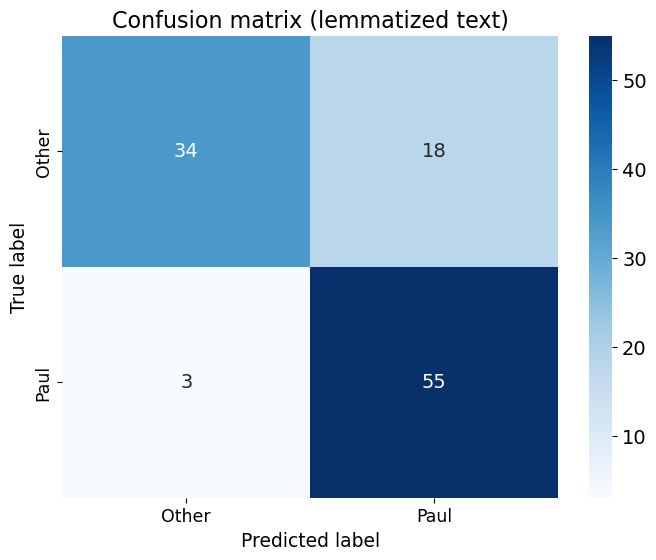

In [19]:
# Plot confusion matrix
conf_matrix_lem = confusion_matrix(y_test_decoded_lem, y_pred_decoded_lem)

plt.figure(figsize=(8, 6))
heatmap = sns.heatmap(conf_matrix_lem, annot=True, fmt=".0f", cmap='Blues', annot_kws={"fontsize": 14},
                     xticklabels=label_encoder_lem.classes_, yticklabels=label_encoder_lem.classes_)
plt.xlabel('Predicted label', fontsize=13.5)
plt.ylabel('True label', fontsize=13.5)
plt.title('Confusion matrix (lemmatized text)', fontsize=16)
plt.xticks(fontsize=12.5)
plt.yticks(fontsize=12.5)
cbar = heatmap.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)  

plt.show()

### Predictions

In [20]:
# Functions for predicting authorship for (lemmatized versions of) subset B and C

def preprocess_lem_chunks(chunks):
    sequences = tokenizer_lem.texts_to_sequences(chunks)
    sequences_padded = pad_sequences(sequences, maxlen=max_sequence_length_lem, padding='post')
    
    return sequences_padded


def get_predictions_lem(chunks):
    preprocessed_lem_chunks = preprocess_lem_chunks(chunks)
    
    predictions_prob = model_lem.predict(preprocessed_lem_chunks)
    predicted_labels = label_encoder_lem.inverse_transform(np.argmax(predictions_prob, axis=1))
    
    return predicted_labels, predictions_prob


def plot_probabilities_lem(letter_title, subset, predictions_prob):
    color = "#006400" if subset == "B" else "#380282"
    
    probabilities_paul = predictions_prob[:, label_encoder_lem.transform(['Paul'])[0]]
    chunk_numbers = range(1, len(probabilities_paul) + 1)

    plt.figure(figsize=(8, 6))
    plt.plot(chunk_numbers, probabilities_paul, marker='o', linestyle='-', color=color)
    plt.xlabel('Chunk number', fontsize=14)
    plt.ylabel('Probability of Paul', fontsize=14)
    plt.title(f'Predicted probabilities of Paul for {letter_title} (lemmatized)', fontsize=16)

    num_ticks = min(10, len(probabilities_paul))
    step = max(1, len(probabilities_paul) // num_ticks)
    xticks_values = range(1, len(probabilities_paul) + 1, step)
    plt.xticks(xticks_values, fontsize=12)
    plt.yticks(fontsize=12)
    plt.ylim(-0.001, 1.03)
    
    plt.show()


def print_and_plot_predictions_lem(letter_title, subset, chunks):
    predicted_labels, predictions_prob = get_predictions_lem(chunks)
    
    print(f"Predicted author for lemmatized chunks of {letter_title}:", predicted_labels)
    plot_probabilities_lem(letter_title, subset, predictions_prob)
    
    return predicted_labels


1/1 [==============================] - 0s 45ms/step
Predicted author for lemmatized chunks of 1 Peter: ['Paul' 'Paul' 'Paul' 'Paul' 'Paul' 'Other' 'Other' 'Paul' 'Other' 'Paul'
 'Paul' 'Paul' 'Other' 'Paul' 'Paul' 'Paul' 'Paul' 'Other' 'Paul']


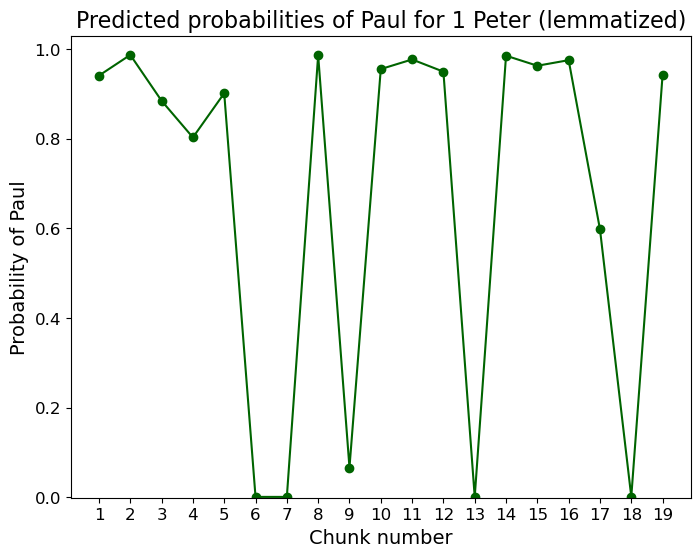

1/1 [==============================] - 0s 30ms/step
Predicted author for lemmatized chunks of Jude: ['Other' 'Other' 'Paul' 'Other' 'Other' 'Other']


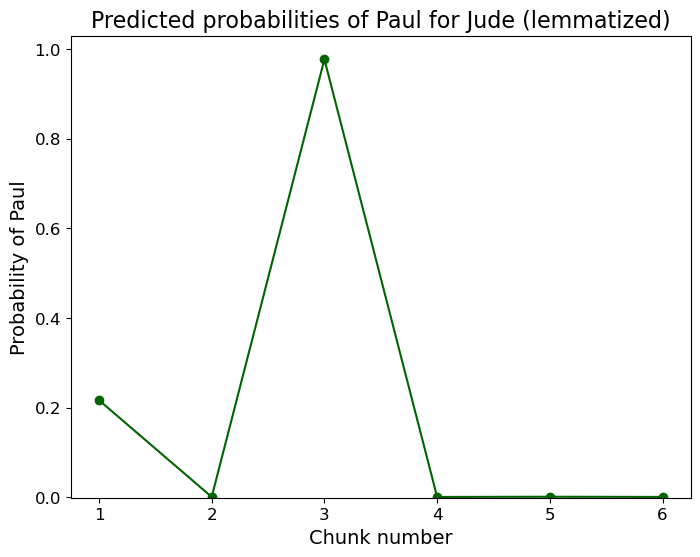

1/1 [==============================] - 0s 25ms/step
Predicted author for lemmatized chunks of Philemon: ['Paul' 'Paul' 'Paul' 'Paul']


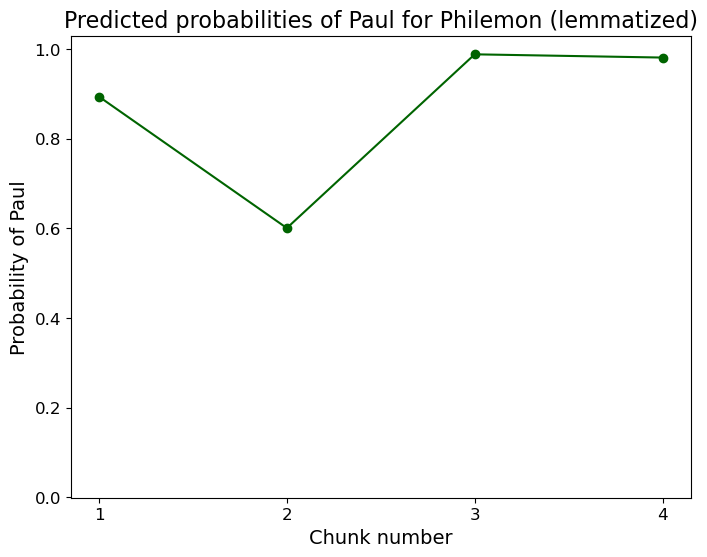

1/1 [==============================] - 0s 35ms/step
Predicted author for lemmatized chunks of Galatians: ['Other' 'Paul' 'Paul' 'Other' 'Paul' 'Paul' 'Paul' 'Paul' 'Paul' 'Paul'
 'Paul' 'Paul' 'Paul' 'Paul' 'Other' 'Paul' 'Paul' 'Other' 'Paul' 'Paul'
 'Paul' 'Paul' 'Paul' 'Paul' 'Paul']


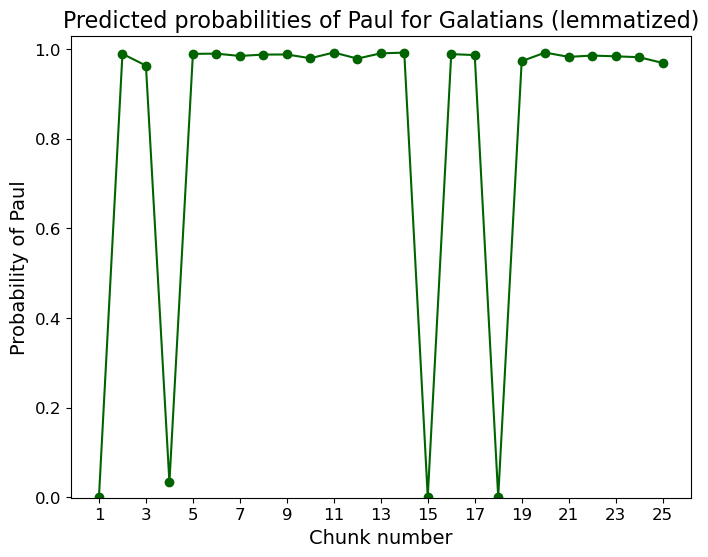

1/1 [==============================] - 0s 29ms/step
Predicted author for lemmatized chunks of 2 Timothy: ['Paul' 'Paul' 'Paul' 'Other' 'Paul' 'Other' 'Other' 'Paul' 'Paul' 'Paul'
 'Paul' 'Other' 'Paul' 'Paul' 'Paul']


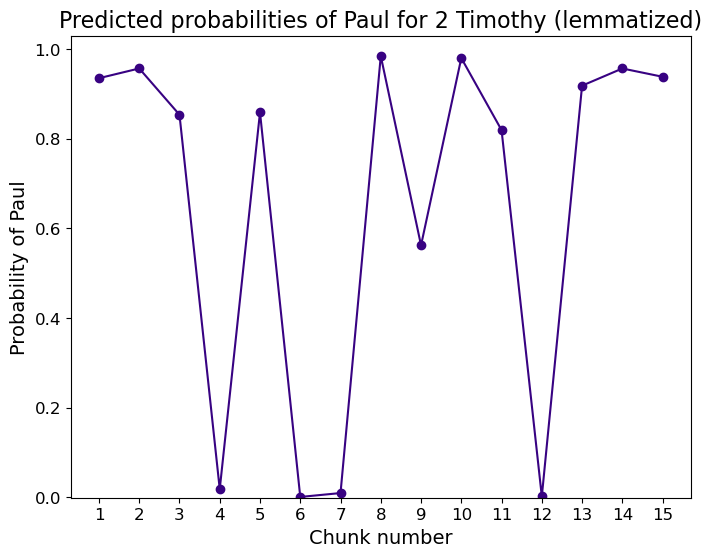

1/1 [==============================] - 0s 28ms/step
Predicted author for lemmatized chunks of Titus: ['Other' 'Other' 'Paul' 'Paul' 'Other' 'Other' 'Paul' 'Paul']


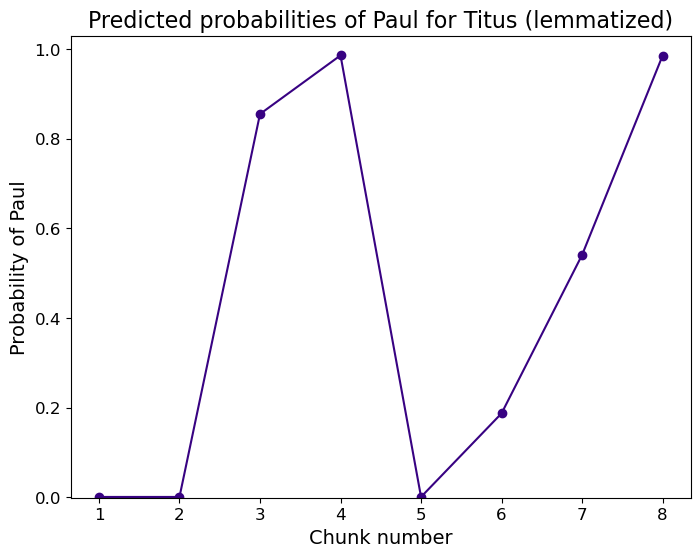

1/1 [==============================] - 0s 30ms/step
Predicted author for lemmatized chunks of 2 Thessalonians: ['Paul' 'Other' 'Paul' 'Paul' 'Other' 'Paul' 'Paul' 'Paul' 'Paul' 'Paul']


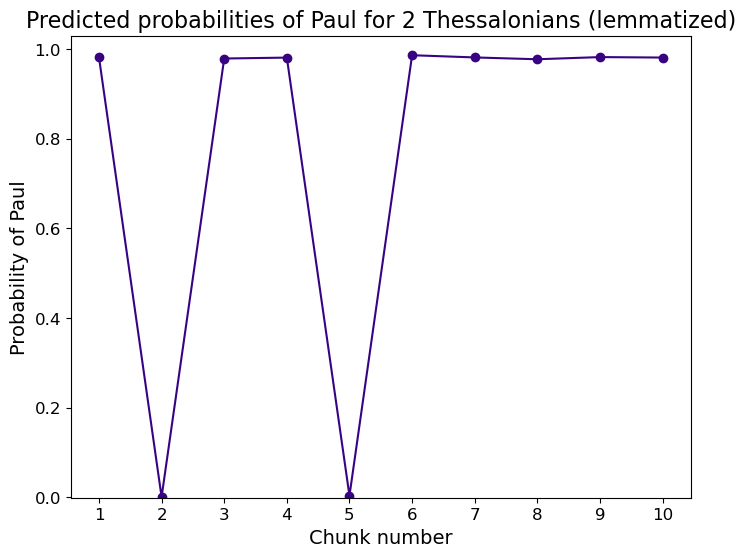

1/1 [==============================] - 0s 31ms/step
Predicted author for lemmatized chunks of 1 Timothy: ['Other' 'Paul' 'Other' 'Other' 'Paul' 'Paul' 'Paul' 'Other' 'Other'
 'Other' 'Paul' 'Paul' 'Other' 'Paul' 'Other' 'Other' 'Other' 'Other']


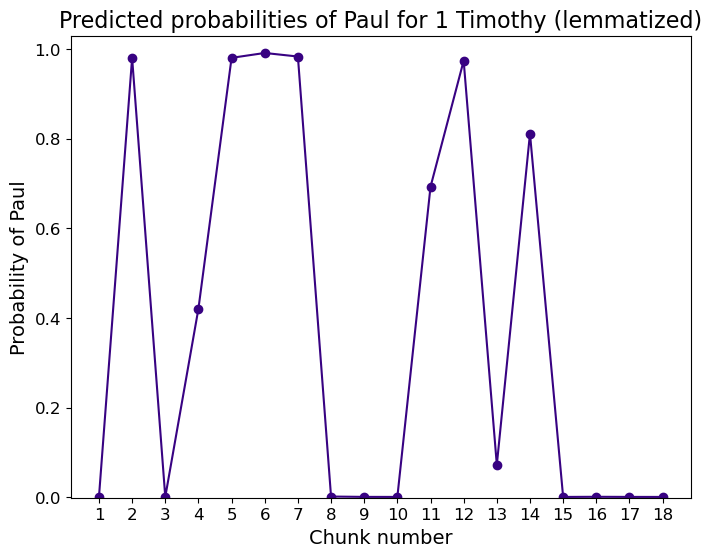

1/1 [==============================] - 0s 36ms/step
Predicted author for lemmatized chunks of Ephesians: ['Paul' 'Paul' 'Paul' 'Other' 'Other' 'Other' 'Paul' 'Paul' 'Paul' 'Paul'
 'Paul' 'Other' 'Paul' 'Paul' 'Paul' 'Other' 'Paul' 'Paul' 'Paul' 'Paul'
 'Paul' 'Paul' 'Other' 'Paul' 'Other' 'Paul' 'Paul' 'Other']


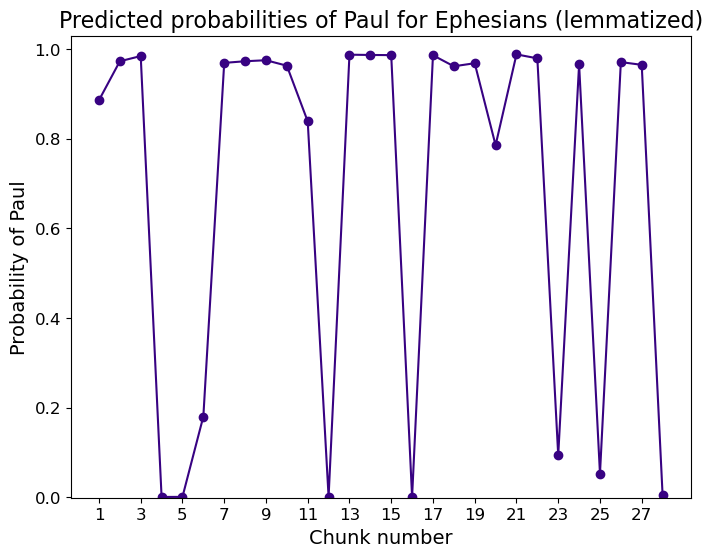

2/2 [==============================] - 0s 19ms/step
Predicted author for lemmatized chunks of Hebrews: ['Other' 'Other' 'Other' 'Other' 'Paul' 'Other' 'Other' 'Other' 'Paul'
 'Paul' 'Other' 'Other' 'Paul' 'Other' 'Other' 'Paul' 'Other' 'Other'
 'Paul' 'Other' 'Other' 'Paul' 'Paul' 'Other' 'Other' 'Other' 'Other'
 'Other' 'Paul' 'Other' 'Other' 'Other' 'Paul' 'Paul' 'Other' 'Paul'
 'Other' 'Other' 'Other' 'Other' 'Other' 'Other' 'Other' 'Other' 'Other'
 'Paul' 'Paul' 'Paul' 'Paul' 'Paul' 'Paul' 'Other' 'Paul' 'Paul' 'Other'
 'Other' 'Paul' 'Paul']


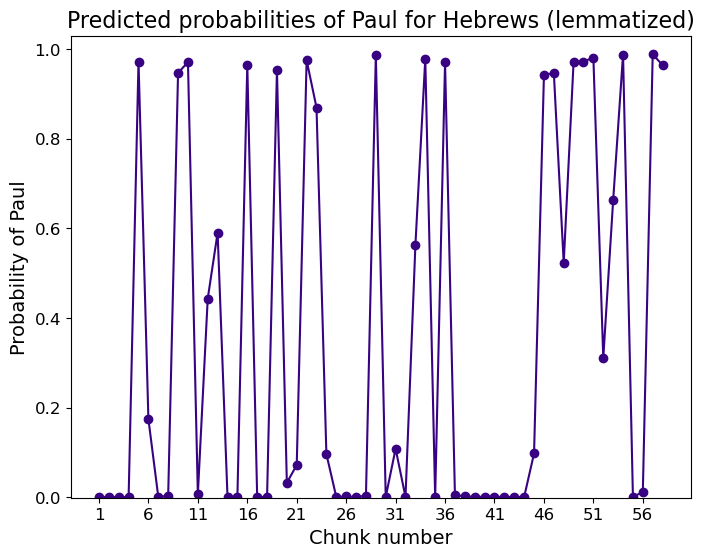

1/1 [==============================] - 0s 35ms/step
Predicted author for lemmatized chunks of Colossians: ['Paul' 'Other' 'Paul' 'Paul' 'Paul' 'Paul' 'Paul' 'Paul' 'Paul' 'Paul'
 'Paul' 'Paul' 'Paul' 'Paul' 'Paul' 'Paul' 'Paul' 'Paul' 'Other' 'Paul'
 'Paul']


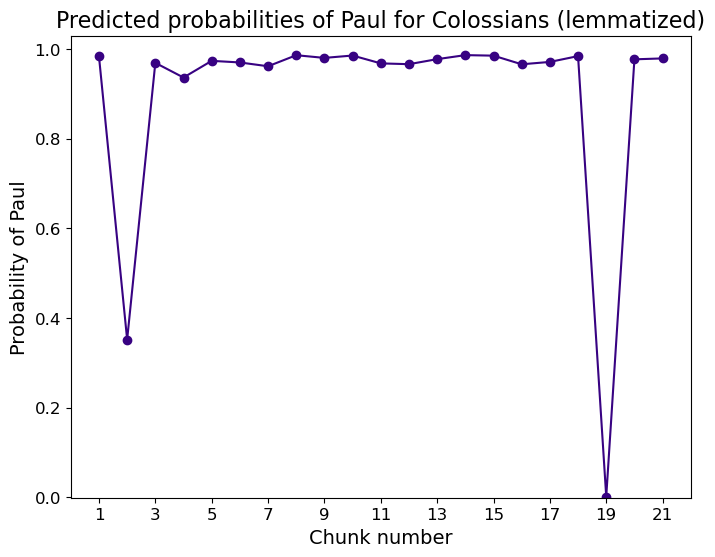

In [21]:
# Printing and plotting predictions for subset B and C

# Subset B: letters (with known authorship) left out of subset A
for letter_title, chunks in subset_B_lem.items():
    print_and_plot_predictions_lem(letter_title, "B", chunks)

# Subset C: disputed Pauline letters
for letter_title, chunks in subset_C_lem.items():
    print_and_plot_predictions_lem(letter_title, "C", chunks)